# 1. 합성곱 신경망 (CNN, Convolutional NN)
: 이미지 인식의 혁신

## 1-1. 왜 이미지 처리에 MLP가 아닌 CNN을 사용할까?
1. 이미지 구조 유지 → CNN
2. CNN : Convolution으로 특징(feature) 추출 + Pooling으로 차원 축소 = 어떤 영역에 특정한 특징이 존재하는가를 보기 때문에 위치에 무관
3. 효율적인 파라미터 사용
4. 공간 정보를 보존하면서 학습

## 1-2. 합성곱(Convolution)과 풀링(Pooling)
: 이미지의 특징을 추출하는 방법

- CNN 모델은 크게 두 부분으로 나뉨:
1. 특징 추출 (Feature Learning) - Convolution, Pooling이 담당
2. 클래스 분류 (Classification) - Fully Connected Layer가 담당  
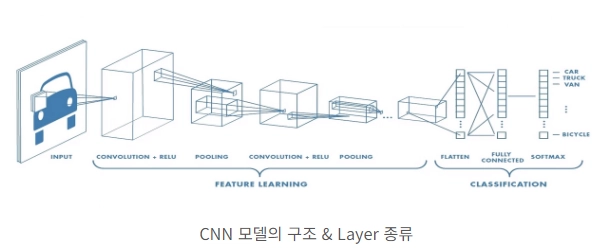

- **Convolution Layer**  
: 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징을 학습 -> 결과를 Feature Map에 저장 
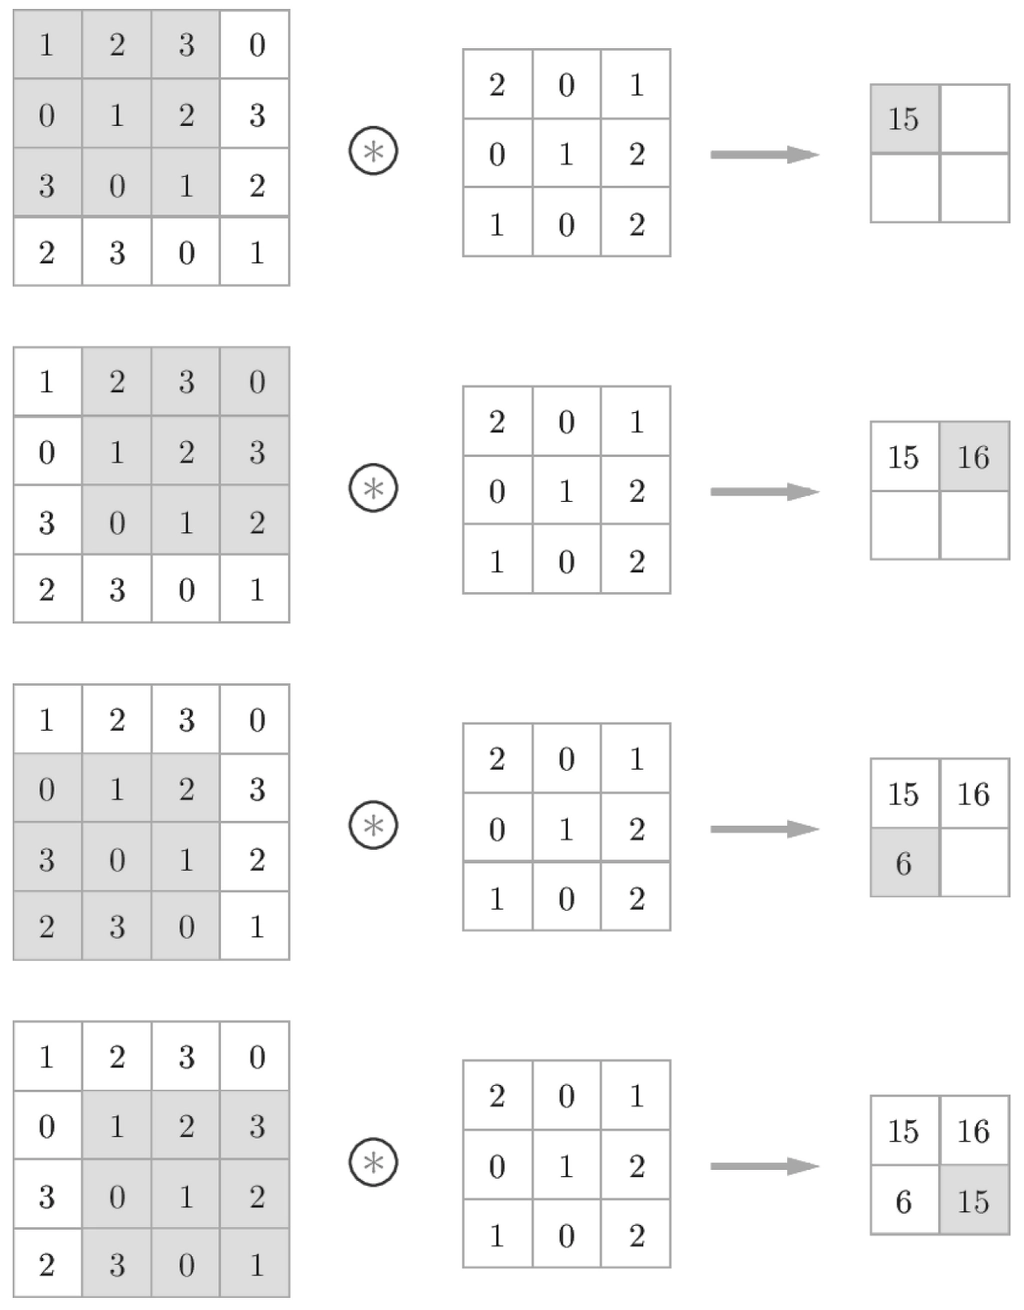  
- **Padding** : 이미지 바깥을 0으로 둘러쌈 (가장자리 특징 보존)
- **Stride** : 이미지를 몇 칸씩 점프하면서 훑을 것인지 결정 (커질수록 feature map 크기 감소)
- **Pooling** : 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것  
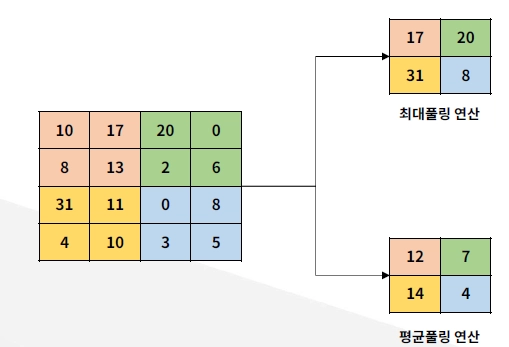  
    - 장점 : 모델 용량, 계산량, 노이즈, 과적합 감소
    - 단점 : 정보 소실 위험

### 정리
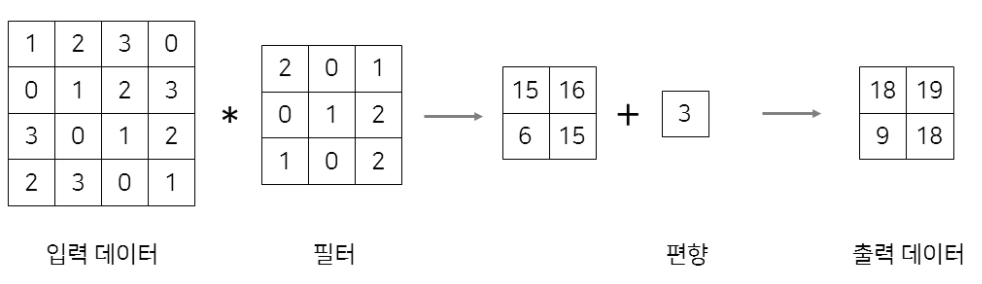  
- Convolution과 Pooling을 이용해 특징 추출을 진행
- 연산 과정에서 출력(feature map)의 크기와 정보 보존 정도를 조절하기 위한 하이퍼파라미터로 padding, stride가 활용됨

## 1-3. 대표적인 CNN 아키텍처 살펴보기
1. AlexNet (2012)
- 머신러닝에서 벗어나 최초로 GPU를 이용해 학습한 대규모 CNN 모델
- ReLU 사용(기울기 소실 문제 해소)
2. VGGNet (2014)
- 이미지 인식에 강한 깊은 층의 CNN 모델
- 이미 만들고 학습시킨 VGGNet 모델을 가져와 사용하는 전이 학습에 많이 쓰는 모델
3. ResNet (2015)
- 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결한 모델
- 현재까지도 많은 모델의 기반이 되는 구조

# 2. 이미지 딥러닝 응용
## 2-1. 이미지 분류 (Image Classification)
이미지를 수치 데이터(픽셀 값)로 인식 → 사전 정의된 클래스 중 하나로 분류
| 모델명 | 특징 요약 | 주의사항 |
| --- | --- | --- |
| **AlexNet** | 비교적 단순한 구조, 초기 CNN 모델들 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| **VGG** | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
| **ResNet** | Residual 연결 (skip connections) → 매우 깊은 네트워크 가능 | 과적합 주의, batch size / regularization 조절 필요 |
| **Vision Transformer (ViT)** | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |

## 2-2. 객체 탐지 (Object Detection)
객체 검출(object detection)은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업
- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올림:
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측
- 대표 모델: YOLO, Faster R-CNN, SSD 등

## 2-3. 이미지 캡셔닝 (Image Captioning)
image captioning은 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현
- 이미지 특징을 추출하기 위한 CNN과 문장으로 나타내기 위한 RNN
    - CNN을 이용한 특징 추출
    - Attention Network를 이용하여 단어 생성(중요한 부분에 가중치)
    - RNN을 이용하여 문장 완성

### CNN 세 줄 요약
- CNN은 (Conv + Pool)의 반복으로 특징을 학습(Feature Learning)하고,
- FC Layer를 적용하여 이미지를 분류(Classification)한다.
- 이때, (Conv + Pool)에 여러 방법을 적용할 수 있으며, 그에 따라 모델의 성능이 달라진다.

# 3. 과거를 기억하는 신경망: RNN (Recurrent Neural Network)
## 3-1. 순차(Sequence) 데이터란?
- 순차 데이터(Sequence Data) : 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터
- 순차 데이터의 특징
    - 요소의 순서 의존성: 데이터를 구성하는 요소들의 순서 자체가 핵심 정보
    - 자기상관성: 이전 시점의 데이터가 다음 시점의 데이터에 영향을 미침  

⇒ 과거의 정보를 기억하고, 순서의 의미를 학습할 수 있는 특별한 신경망이 필요하다!

## 3-2. RNN의 구조와 원리
1. 시퀀스 데이터를 입력받아 순서 정보를 유지하며 처리한다.
2. 순환하는 은닉층이 매 시점의 은닉 상태를 업데이트한다.
3. 이전 시점의 값을 현재 시점으로 넘겨준다.
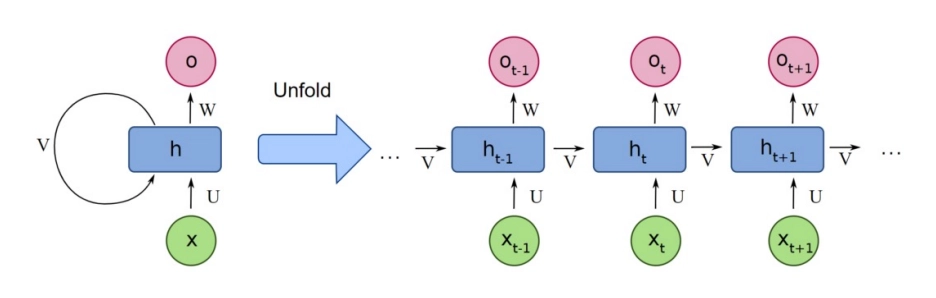  
- 초록색은 입력층, 파란색은 은닉층, 분홍색은 출력층을 의미한다.
- x:입력 / h:은닉 상태 / o:출력 / u:입력->은닉상태 가중치 / v:이전 은닉 상태 -> 현재 은닉 상태 가중치 / w:은닉 상태->출력 가중치

### RNN의 핵심 원리: 가중치 공유
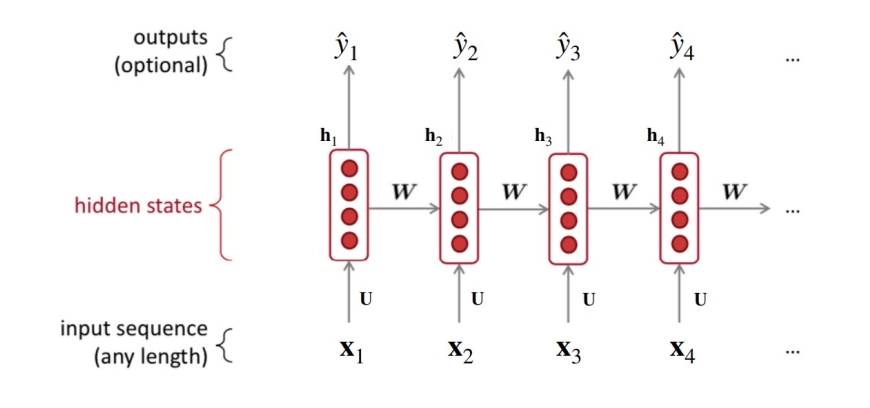  
$X_1$을 처리할 때, $X_2$를 처리할 때, 그리고 $X_n$을 처리할 때까지 모두 동일한 파라미터(입력 가중치(U), 순환 가중치(W), 편향(b)) 를 공유하는 구조
- 가중치 공유의 이점
    - 입력 시퀀스의 길이가 아무리 길어져도 학습해야 할 파라미터의 수가 일정하게 유지된다.
    - 이전 시점까지의 정보와 현재 시점의 입력이 주어졌을 때, 어떻게 상태(메모리)를 업데이트할 것인가?라는 하나의 일반적 규칙을 학습 -> 일반화 능력 향상

## 3-3. RNN의 한계 및 장기 의존성 문제 (The Long-Term Dependency Problem)
- 기울기 소실 (Vanishing Gradients)
    - 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 작을 때
    - 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상
- 기울기 폭주 (Exploding Gradients)
    - 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 클 때
    - 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제
- 느린 훈련 시간
    - 순차적 계산을 해야 하는 구조적 한계
    - 전체 시퀀스를 한 번에 병렬 처리 불가능
### 장기 의존성 문제 (Long-Term Dependency Problem)
- 위 3가지 RNN의 한계는 장기 의존성 문제로 이어짐
- 시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상
- 모델의 ‘단기 기억력’은 준수했지만, ‘장기 기억력’에 문제 발생
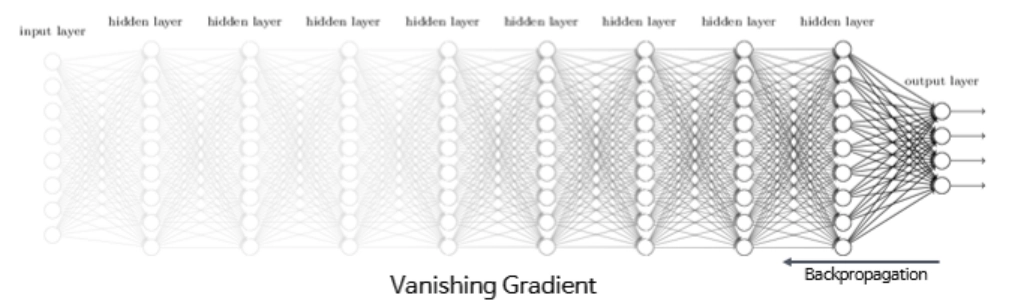  
- 더 길고 복잡한 시퀀스 데이터를 안정적으로 다룰 수 있는 새로운 모델 필요성 대두

# 4. 똑똑하게 기억하고 잊는 법: LSTM & GRU
### 4-1. 게이트(Gate)로 정보의 흐름을 제어하다: LSTM
- **셀 상태 ($C_t$ - 장기 기억)**: 이 기억은 절대 변하지 않는 핵심 기억입니다.

- **엘리트 (은닉 상태 $h_t$ - 단기 기억/출력)**:  현재 상황에서 바로 사용하는 기억입니다. 셀 상태에서 필요한 정보만 꺼내서, 지금 시점에서의 판단이나 출력으로 사용합니다

1. **“이 기억은 잊자” (Forget Gate)**: ($C_{t-1}$)는 잊어버리자!
2. **“이건 기억하자” (Input Gate)**: ($x_t$)는 핵심 기억($C_t$)에 저장하자.
3. **“이렇게 행동하자!” (Output Gate)**: ($C_t$)를 바탕으로, 결과 ($h_t$) 출력.

### 4-2. 더 단순하고 효율적인 구조: GRU (Gated Recurrent Unit)
모든 기억과 행동이 하나의 상태($h_t$)로 통합되어 있습니다

- **과거 기억 vs 새 정보, 몇 대 몇? (Update Gate)**
    - ($h_{t-1}$)이 30% 있어도, ($x_t$)가  70% 더 중요합니다.
- **과거 기억은 얼마나 무시해야 할까? (Reset Gate)**
    - 새로운 자극이 강렬하면, 과거 기억은 잠시 무시합니다.
    - 방금 엄마한테 혼났지만($h_{t-1}$), 액션가면($x_t$)이 시작하네! → TV 앞으로 간다.

### 4-3. LSTM vs GRU: 언제 무엇을 선택할까?
**LSTM vs GRU 비교분석표**

| 구분 | LSTM | GRU |
| --- | --- | --- |
| **구조** | 3개 게이트 (입력, 삭제, 출력) | 2개 게이트 (업데이트, 리셋) |
| **복잡도** | 더 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음 |
| **학습 속도** | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| **메모리 사용량** | 큼 | 작음 |
| **장기 의존성 처리** | 더 강력 | LSTM과 비교해 다소 약함 |
| **연구/사례 축적** | 매우 많음 | 비교적 적음 (최근 등장) |
| **성능** | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |
|**예시** | 기계 번역, 언어 모델링, 장기 시계열 예측(금융, 기후 등) | 음성 인식, 스트리밍 데이터, 실시간 비디오 분석, 짧은 시퀀스 기반의 텍스트 분류 |

# 5. 문장을 입력받아 문장을 출력하다: Seq2Seq
한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용된다.
- 특징
    - 입력과 출력의 길이가 달라도 된다!
    - 인코더와 디코더가 분리되어 있다!
    - 문맥 벡터라는 다리를 건넌다!
## 5-1. Seq2Seq의 기본 구조: 인코더와 디코더
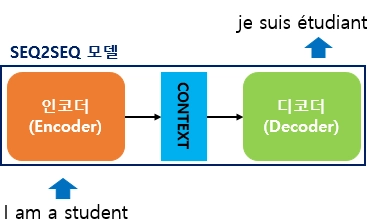  
- 인코더 : 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비 (원문의 특징 파악) -> 컨텍스트 벡터(요약 정보)
- 디코더 : 압축된 정보를 바탕으로 원하는 시퀀스를 생성. (번역문 생성)
    - 기본적인 seq2seq에서는, 인코더가 보내준 컨텍스트 벡터는 디코더의 첫번째 은닉 상태에 사용된다.
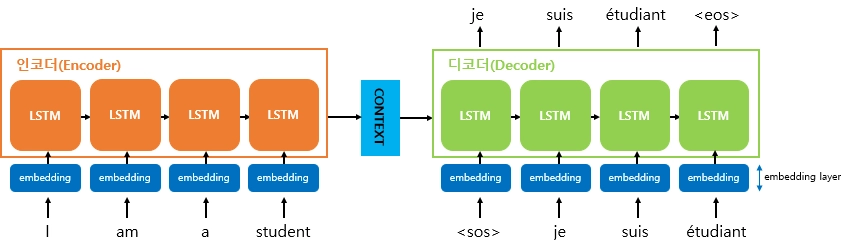

- 인코더와 디코더 모두 그림과 같이 RNN(or LSTM/GRU)를 여러개 조합한 형태이다.
- 모든 단어는 워드 임베딩(word2vec) 과정을 거친다.

- 컨텍스트 벡터 : 인코더 중 마지막 시점의 은닉 상태(hidden state)
    - 입력 시퀀스(입력된 문장)의 요약 정보처럼 작동. 


## 5-2. Seq2Seq의 한계: 병목 현상 (Bottleneck)
즉, 고정된 Context Vector에 소스 문장의 정보 압축 → 병목 현상 발생!!(입력 시퀀스의 정보가 손실됨)

→ 이러한 한계를 해결하기 위해 다음 세션에서 배울 Attention 메커니즘이 도입됩니다!